# Experiment B — MPJPE and normalized PCK vs optical-flow period

This notebook evaluates Experiment B using either **DHP19** or **eH36M**.

Modify only `DATASET` in the configuration cell:

```python
DATASET = "dhp19"
# or
DATASET = "eh36m"
```

The selected dataset automatically controls:

- the experiment result folder;
- the ground-truth root;
- the image resolution used for validity checks;
- the mapping from the prediction sequence/channel to the GT skeleton folder;
- the output directory and dataset label.

The metric definitions remain aligned with Experiment A:

- normalized PCK reference joints: `REF_JOINT_1 = 1`, `REF_JOINT_2 = 5`;
- normalized PCK thresholds: `[0.1, 0.2, 0.4, 0.6]`;
- dataset MPJPE weighted by evaluated joint-point count;
- dataset PCK computed from total correct joint points divided by total evaluated joint points.


In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 180)

try:
    from datasets.utils import constants as ds_constants, parsing as ds_parsing
    DATASET_UTILS_AVAILABLE = True
except Exception as exc:
    DATASET_UTILS_AVAILABLE = False
    DATASET_UTILS_IMPORT_ERROR = repr(exc)

# =============================================================================
# USER CONFIGURATION
# =============================================================================

# Allowed values: "dhp19", "eh36m"
DATASET = "dhp19"

# Optional overrides. Keep them as None to use the selected dataset preset.
RESULTS_DIR = None
DATA_ROOT_OVERRIDE = None
ANALYSIS_OUT_DIR_OVERRIDE = None

# Results root: /data in Docker, ~/data when run directly on a PC.
DATA_DIR = next((p for p in (Path('/data'), Path.home() / 'data') if p.exists()), Path('/data'))
EXP_B_DIR = DATA_DIR / 'MoveEnet_OFK_results'

DATASET_PRESETS = {
    "dhp19": {
        "label": "DHP19",
        "experiment_folder": "MOFK_dhp19_full_test",
        "data_root": DATA_DIR / "dhp19_testing_set_S13toS17",
        "image_width_px": 346,
        "image_height_px": 260,
        # DHP19 GT follows the DVS channel:
        # ch2dvs -> ch2GT200Hzskeleton, ch3dvs -> ch3GT200Hzskeleton.
        "gt_rates_hz": (200,),
    },
    "eh36m": {
        "label": "eH36M",
        "experiment_folder": "MOFK_eh36m_full_test",
        "data_root": DATA_DIR / "eh36m_testing_set_S9S11/events",
        "image_width_px": 640,
        "image_height_px": 480,
        # The current experiments normally use the 200 Hz GT folder.
        # The 50 Hz folder is retained as a fallback for sequences stored with
        # the original Human3.6M ground-truth rate.
        "gt_rates_hz": (200,),
    },
}

DATASET = str(DATASET).strip().lower()
if DATASET not in DATASET_PRESETS:
    raise ValueError(
        f"Unknown DATASET={DATASET!r}. Expected one of: "
        f"{sorted(DATASET_PRESETS)}"
    )

DATASET_CFG = DATASET_PRESETS[DATASET]
DATASET_LABEL = DATASET_CFG["label"]
EXPERIMENT_FOLDER = DATASET_CFG["experiment_folder"]
DATA_ROOT = (
    Path(DATA_ROOT_OVERRIDE).expanduser()
    if DATA_ROOT_OVERRIDE is not None
    else DATASET_CFG["data_root"]
)

N_JOINTS = 13
IMAGE_WIDTH_PX = int(DATASET_CFG["image_width_px"])
IMAGE_HEIGHT_PX = int(DATASET_CFG["image_height_px"])

# Normalized thresholds, intentionally identical to Experiment A.
PCK_THRESHOLDS_NORM = [0.1, 0.2, 0.4, 0.6]
PRIMARY_PCK_THRESHOLD = 0.4

# Same normalized-PCK reference joints used in Experiment A.
REF_JOINT_1 = 1
REF_JOINT_2 = 5

# Keep False for strict comparability with Experiment A.
USE_VALID_GT_MASK_FOR_METRICS = False
IGNORE_GT_ZERO_ZERO = True
IGNORE_GT_OUTSIDE_IMAGE = True

# Use only when prediction and GT timestamps have a known constant offset.
PRED_TIMESTAMP_OFFSET_S = 0.0

# Optional manual GT folder, relative to each sequence directory.
# Example: "ch0GT200Hzskeleton"
FORCE_GT_FOLDER = None

OUTPUT_PREFIX = f"experimentB_{DATASET}"

if DATASET_UTILS_AVAILABLE:
    joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
else:
    joint_names = [f"joint{i}" for i in range(N_JOINTS)]

if len(joint_names) < N_JOINTS:
    joint_names += [f"joint{i}" for i in range(len(joint_names), N_JOINTS)]
joint_names = joint_names[:N_JOINTS]


# check for known corrupted eH36M GT files. The whole sequence is skipped for every method.
CORRUPTED_EH36M_GT_FILES = [
    "cam4_S11_Greeting/ch0GT200Hzskeleton/data.log",
    "cam4_S9_Eating/ch0GT200Hzskeleton/data.log",
    "cam4_S9_Greeting/ch0GT200Hzskeleton/data.log",
    "cam4_S9_Photo/ch0GT200Hzskeleton/data.log",
    "cam4_S9_Photo_1/ch0GT200Hzskeleton/data.log",
    "cam4_S9_SittingDown_1/ch0GT200Hzskeleton/data.log",
    "cam4_S9_Waiting_1/ch0GT200Hzskeleton/data.log",
    "Cam4_S9_Walking/ch0GT200Hzskeleton/data.log",
]

CORRUPTED_EH36M_GT_FILES_NORMALIZED = {
    Path(path).as_posix().lower()
    for path in CORRUPTED_EH36M_GT_FILES
}

print("DATASET:", DATASET)
print("DATASET_LABEL:", DATASET_LABEL)
print("DATA_ROOT:", DATA_ROOT)
print("IMAGE_SIZE:", f"{IMAGE_WIDTH_PX}x{IMAGE_HEIGHT_PX}")
print("DATASET_UTILS_AVAILABLE:", DATASET_UTILS_AVAILABLE)

if not DATASET_UTILS_AVAILABLE:
    print("Import error:", DATASET_UTILS_IMPORT_ERROR)
    print(
        "Run this notebook in the same environment as the experiment, "
        "or add the project repository to PYTHONPATH."
    )

print("\nJoint indices:")
for i, name in enumerate(joint_names):
    tag = ""
    if i == REF_JOINT_1:
        tag = "  <-- REF_JOINT_1"
    if i == REF_JOINT_2:
        tag = "  <-- REF_JOINT_2"
    print(f"  {i:2d}: {name}{tag}")

print(
    f"\nNormalized PCK reference: "
    f"{REF_JOINT_1} ({joint_names[REF_JOINT_1]}) -> "
    f"{REF_JOINT_2} ({joint_names[REF_JOINT_2]})"
)
print("PCK thresholds:", PCK_THRESHOLDS_NORM)


DATASET: eh36m
DATASET_LABEL: eH36M
DATA_ROOT: /data/eh36m_testing_set_S9S11/events
IMAGE_SIZE: 640x480
DATASET_UTILS_AVAILABLE: True

Joint indices:
   0: head
   1: shoulder_right  <-- REF_JOINT_1
   2: shoulder_left
   3: elbow_right
   4: elbow_left
   5: hip_left  <-- REF_JOINT_2
   6: hip_right
   7: wrist_right
   8: wrist_left
   9: knee_right
  10: knee_left
  11: ankle_right
  12: ankle_left

Normalized PCK reference: 1 (shoulder_right) -> 5 (hip_left)
PCK thresholds: [0.1, 0.2, 0.4, 0.6]


## 1. Find prediction CSVs


In [2]:
def decode_period_token(token):
    value = float(str(token).strip().replace("p", "."))
    if value <= 0:
        raise ValueError(f"Period must be greater than zero, got {token!r}")
    return value


def _is_results_dir(path):
    path = Path(path)
    return path.is_dir() and (path / "raw").is_dir()


def find_results_dir():
    if RESULTS_DIR is not None:
        path = Path(RESULTS_DIR).expanduser().resolve()
        if not _is_results_dir(path):
            raise FileNotFoundError(
                f"RESULTS_DIR does not contain raw/: {path}"
            )
        return path

    candidates = []

    # Standard project layout.
    candidates.append(EXP_B_DIR / EXPERIMENT_FOLDER / "results")

    # Resolve the selected dataset relative to the current notebook location.
    cwd = Path.cwd().resolve()
    search_bases = [cwd, *list(cwd.parents)[:8]]

    for base in search_bases:
        candidates.append(base / EXPERIMENT_FOLDER / "results")

        # Notebook launched from inside <dataset>_full_test/.
        if base.name == EXPERIMENT_FOLDER:
            candidates.append(base / "results")

        # Notebook launched from inside the selected results/raw directory.
        if base.name == "results" and base.parent.name == EXPERIMENT_FOLDER:
            candidates.append(base)
        if (
            base.name == "raw"
            and base.parent.name == "results"
            and base.parent.parent.name == EXPERIMENT_FOLDER
        ):
            candidates.append(base.parent)

    unique_candidates = []
    seen = set()
    for candidate in candidates:
        candidate = Path(candidate).expanduser()
        key = str(candidate)
        if key not in seen:
            unique_candidates.append(candidate)
            seen.add(key)

    for candidate in unique_candidates:
        if _is_results_dir(candidate):
            return candidate.resolve()

    checked = "\n".join(f"  - {p}" for p in unique_candidates)
    raise FileNotFoundError(
        f"Could not find the Experiment-B results for DATASET={DATASET!r}.\n"
        f"Expected dataset folder: {EXPERIMENT_FOLDER}\n"
        f"Checked:\n{checked}\n"
        "Set RESULTS_DIR manually only if your result folder uses a different layout."
    )


def discover_prediction_csvs(raw_dir):
    # Historical Experiment-B layout is net_*/fp_*.
    # The additional patterns keep compatibility with np_* naming and with
    # folders whose network/flow order was reversed.
    patterns = [
        "net_*/fp_*/*.csv",
        "np_*/fp_*/*.csv",
        "fp_*/net_*/*.csv",
        "fp_*/np_*/*.csv",
    ]

    files = []
    seen = set()
    for pattern in patterns:
        for path in sorted(raw_dir.glob(pattern)):
            resolved = path.resolve()
            if resolved not in seen:
                files.append(path)
                seen.add(resolved)
    return sorted(files)


RESULTS = find_results_dir()
RAW_DIR = RESULTS / "raw"
LOG_DIR = RESULTS / "logs"

if ANALYSIS_OUT_DIR_OVERRIDE is None:
    ANALYSIS_OUT_DIR = RESULTS / "analysis_outputs_expB"
else:
    ANALYSIS_OUT_DIR = Path(ANALYSIS_OUT_DIR_OVERRIDE).expanduser()

ANALYSIS_OUT_DIR.mkdir(parents=True, exist_ok=True)
csv_files = discover_prediction_csvs(RAW_DIR)

print("DATASET:", DATASET)
print("RESULTS:", RESULTS)
print("RAW_DIR:", RAW_DIR)
print("ANALYSIS_OUT_DIR:", ANALYSIS_OUT_DIR)
print("CSV files:", len(csv_files))

for path in csv_files[:5]:
    print("  ", path.relative_to(RESULTS))

if not csv_files:
    raise RuntimeError(
        "No prediction CSV files found. Expected one of these layouts under raw/: "
        "net_*/fp_*/*.csv, np_*/fp_*/*.csv, fp_*/net_*/*.csv, fp_*/np_*/*.csv"
    )


DATASET: eh36m
RESULTS: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results
RAW_DIR: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/raw
ANALYSIS_OUT_DIR: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB
CSV files: 1080
   raw/net_0p02/fp_0p005/cam2_S11_Directions_1__ch0dvs__moveenet_ofk_fp_0p005.csv
   raw/net_0p02/fp_0p005/cam2_S11_Directions__ch0dvs__moveenet_ofk_fp_0p005.csv
   raw/net_0p02/fp_0p005/cam2_S11_Discussion_1__ch0dvs__moveenet_ofk_fp_0p005.csv
   raw/net_0p02/fp_0p005/cam2_S11_Discussion_2__ch0dvs__moveenet_ofk_fp_0p005.csv
   raw/net_0p02/fp_0p005/cam2_S11_Eating_1__ch0dvs__moveenet_ofk_fp_0p005.csv


## 2. Loaders and metadata helpers


In [3]:
def parse_config_from_path(csv_path):
    rel = csv_path.relative_to(RAW_DIR)
    network_token = None
    flow_token = None

    for part in rel.parts[:-1]:
        if part.startswith("net_"):
            network_token = part[len("net_"):]
        elif part.startswith("np_"):
            network_token = part[len("np_"):]
        elif part.startswith("fp_"):
            flow_token = part[len("fp_"):]

    if network_token is None or flow_token is None:
        raise ValueError(
            f"Could not recover network/flow periods from path: {rel}"
        )

    network_period_s = decode_period_token(network_token)
    flow_period_s = decode_period_token(flow_token)

    return {
        "flow_period_s": flow_period_s,
        "flow_rate_hz": 1.0 / flow_period_s,
        "network_period_s": network_period_s,
        "detection_rate_hz": 1.0 / network_period_s,
        "net_token": network_token,
        "fp_token": flow_token,
    }


def method_from_csv(csv_path):
    name = csv_path.stem.strip().lower()

    if "moveenet_only" in name or "movenet_only" in name:
        return "MoveEnet only"

    if (
        "moveenet_ofk" in name
        or "movenet_ofk" in name
        or re.search(r"(?:^|_)ofk(?:_|$)", name)
    ):
        return "MoveEnet + OFK"

    # Experiment B contains OFK predictions by default.
    return "MoveEnet + OFK"


def sequence_key_from_csv(csv_path):
    name = csv_path.stem.strip()

    # Prefer the explicit sequence+channel prefix. This accepts both filename
    # separators used by the experiment scripts:
    #   ...__ch2dvs__moveenet_ofk_...
    #   ...__ch2dvs_moveenet_ofk_...
    match = re.match(
        r"^(?P<sequence>.+?__ch\d+dvs)(?=(?:__?|$))",
        name,
        flags=re.IGNORECASE,
    )
    if match:
        return match.group("sequence")

    # Fallback for older outputs without an explicit channel match.
    stripped = re.sub(
        r"__?(?:moveenet|movenet)_(?:ofk|only).*$",
        "",
        name,
        flags=re.IGNORECASE,
    )
    stripped = re.sub(
        r"__?ofk.*$",
        "",
        stripped,
        flags=re.IGNORECASE,
    )

    if not stripped:
        raise ValueError(f"Could not parse sequence key from CSV name: {csv_path.name}")
    return stripped


def split_sequence_and_camera(seq_key):
    parts = seq_key.split("__")
    camera_folder = None
    sequence_parts = parts

    if parts and re.fullmatch(r"ch\d+dvs", parts[-1], flags=re.IGNORECASE):
        camera_folder = parts[-1].lower()
        sequence_parts = parts[:-1]

    if not sequence_parts:
        sequence_parts = [seq_key]

    camera_id = None
    if camera_folder is not None:
        match = re.fullmatch(r"(ch\d+)dvs", camera_folder)
        if match:
            camera_id = match.group(1)

    return sequence_parts, camera_folder, camera_id


def gt_candidates_from_seq_key(seq_key):
    sequence_parts, camera_folder, camera_id = split_sequence_and_camera(seq_key)
    sequence_dir = DATA_ROOT.joinpath(*sequence_parts)

    candidates = []

    if FORCE_GT_FOLDER is not None:
        candidates.append(sequence_dir / FORCE_GT_FOLDER / "data.log")

    if DATASET == "dhp19":
        # DHP19 uses the GT channel corresponding to the prediction DVS channel.
        if camera_id is not None:
            for rate_hz in DATASET_CFG["gt_rates_hz"]:
                candidates.append(
                    sequence_dir
                    / f"{camera_id}GT{rate_hz}Hzskeleton"
                    / "data.log"
                )

    elif DATASET == "eh36m":
        # eH36M prediction files use the event stream ch0dvs. The physical
        # Human3.6M camera is encoded in the sequence name, e.g.
        # cam2_S11_Directions__ch0dvs.
        for rate_hz in DATASET_CFG["gt_rates_hz"]:
            candidates.append(
                sequence_dir
                / f"ch0GT{rate_hz}Hzskeleton"
                / "data.log"
            )

    # Conservative fallbacks for older dataset copies.
    if camera_id is not None:
        for rate_hz in (200, 50):
            candidates.append(
                sequence_dir
                / f"{camera_id}GT{rate_hz}Hzskeleton"
                / "data.log"
            )

    for rate_hz in (200, 50):
        candidates.append(
            sequence_dir
            / f"GT{rate_hz}Hzskeleton"
            / "data.log"
        )

    unique = []
    seen = set()
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate not in seen:
            unique.append(candidate)
            seen.add(candidate)

    return unique


def find_gt_path(seq_key):
    candidates = gt_candidates_from_seq_key(seq_key)
    for path in candidates:
        if path.exists():
            return path, candidates
    return None, candidates


def is_corrupted_gt_file(gt_path):
    if DATASET != "eh36m":
        return False

    gt_path = Path(gt_path)

    try:
        relative_path = gt_path.resolve().relative_to(DATA_ROOT.resolve())
    except ValueError:
        relative_path = gt_path

    normalized_path = relative_path.as_posix().lower()

    return normalized_path in CORRUPTED_EH36M_GT_FILES_NORMALIZED


def load_prediction_csv(csv_path):
    df = pd.read_csv(csv_path)

    if "timestamp" not in df.columns:
        raise ValueError(f"Missing timestamp column in {csv_path}")

    ts = (
        pd.to_numeric(df["timestamp"], errors="coerce").to_numpy(dtype=float)
        + PRED_TIMESTAMP_OFFSET_S
    )
    joints = np.full((len(df), N_JOINTS, 2), np.nan, dtype=np.float64)

    for joint_index in range(N_JOINTS):
        x_candidates = [
            f"joint{joint_index}_x",
            f"pred_joint{joint_index}_x",
            f"pred_j{joint_index}_x",
            f"prediction_joint{joint_index}_x",
        ]
        y_candidates = [
            f"joint{joint_index}_y",
            f"pred_joint{joint_index}_y",
            f"pred_j{joint_index}_y",
            f"prediction_joint{joint_index}_y",
        ]

        x_col = next((col for col in x_candidates if col in df.columns), None)
        y_col = next((col for col in y_candidates if col in df.columns), None)

        if x_col is None or y_col is None:
            raise ValueError(
                f"Missing prediction columns for joint {joint_index} in {csv_path}"
            )

        joints[:, joint_index, 0] = pd.to_numeric(
            df[x_col], errors="coerce"
        ).to_numpy(dtype=float)
        joints[:, joint_index, 1] = pd.to_numeric(
            df[y_col], errors="coerce"
        ).to_numpy(dtype=float)

    return df, ts, joints


def load_gt_data(gt_path):
    if not DATASET_UTILS_AVAILABLE:
        raise RuntimeError(
            "datasets.utils could not be imported. Run this notebook in the "
            "same environment as the experiment."
        )
    return ds_parsing.import_yarp_skeleton_data(
        gt_path,
        multi_channel=False,
    )


def interp_gt_to_pred_ts(gt_data, ts_pred):
    ts_gt_raw = np.asarray(gt_data["ts"], dtype=np.float64)

    if len(ts_gt_raw) == 0:
        raise ValueError("GT file contains no timestamps.")

    ts_gt = np.concatenate(
        ([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0])
    )
    joints_gt = np.zeros(
        (len(ts_pred), N_JOINTS, 2),
        dtype=np.float64,
    )

    for joint_index, joint_name in enumerate(joint_names):
        if joint_name not in gt_data:
            raise KeyError(
                f"GT joint {joint_name!r} not found. "
                f"Available keys: {list(gt_data.keys())[:20]}"
            )

        xy_raw = np.asarray(gt_data[joint_name], dtype=np.float64)
        x = np.concatenate(
            ([xy_raw[0, 0]], xy_raw[:, 0], [xy_raw[-1, 0]])
        )
        y = np.concatenate(
            ([xy_raw[0, 1]], xy_raw[:, 1], [xy_raw[-1, 1]])
        )

        joints_gt[:, joint_index, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, joint_index, 1] = np.interp(ts_pred, ts_gt, y)

    return joints_gt


def valid_gt_mask(joints_gt):
    valid = (
        np.isfinite(joints_gt[:, :, 0])
        & np.isfinite(joints_gt[:, :, 1])
    )

    if IGNORE_GT_ZERO_ZERO:
        valid &= ~(
            (joints_gt[:, :, 0] == 0)
            & (joints_gt[:, :, 1] == 0)
        )

    if IGNORE_GT_OUTSIDE_IMAGE:
        valid &= (
            (joints_gt[:, :, 0] >= 0)
            & (joints_gt[:, :, 0] <= IMAGE_WIDTH_PX)
            & (joints_gt[:, :, 1] >= 0)
            & (joints_gt[:, :, 1] <= IMAGE_HEIGHT_PX)
        )

    return valid


## 3. Normalized PCK implementation

This is the main correction. It uses normalized thresholds, not fixed pixel thresholds.


In [4]:
def calculate_pck_binary(joints_pred: np.ndarray, joints_gt: np.ndarray, threshold: float) -> np.ndarray:
    err_dist = np.linalg.norm(joints_pred - joints_gt, axis=2)

    ref_vec = joints_gt[:, REF_JOINT_2, :] - joints_gt[:, REF_JOINT_1, :]
    ref_dist = np.linalg.norm(ref_vec, axis=1)
    ref_dist = np.maximum(ref_dist, 1e-6)

    return (err_dist <= threshold * ref_dist[:, np.newaxis]).astype(np.float32)

def calculate_pck_binary_masked(joints_pred: np.ndarray, joints_gt: np.ndarray, threshold: float, mask: np.ndarray) -> np.ndarray:
    pck = calculate_pck_binary(joints_pred, joints_gt, threshold).astype(np.float64)
    pck[~mask] = np.nan
    return pck

def compute_sequence_metrics(joints_pred, joints_gt):
    if USE_VALID_GT_MASK_FOR_METRICS:
        raise ValueError(
            "USE_VALID_GT_MASK_FOR_METRICS must be False to match Experiment A. "
            "Experiment A does not mask GT joints during MPJPE/PCK computation."
        )

    err = np.linalg.norm(joints_pred - joints_gt, axis=2)
    valid = valid_gt_mask(joints_gt)

    if USE_VALID_GT_MASK_FOR_METRICS:
        err_for_metrics = err.copy()
        err_for_metrics[~valid] = np.nan
        n_points = int(np.isfinite(err_for_metrics).sum())
        sum_err_px = float(np.nansum(err_for_metrics))
        mpjpe_px = sum_err_px / n_points if n_points else np.nan
        per_joint_err = np.nanmean(err_for_metrics, axis=0)
    else:
        # Exact style from your snippet: err.mean(), err.sum(), err.size.
        err_for_metrics = err
        n_points = int(err.size)
        sum_err_px = float(err.sum())
        mpjpe_px = float(err.mean())
        per_joint_err = err.mean(axis=0)

    row = {
        "n_samples": int(err.shape[0]),
        "n_frames": int(err.shape[0]),
        "sum_err_px": sum_err_px,
        "n_points": n_points,
        "mpjpe_px": mpjpe_px,
    }

    for i, joint in enumerate(joint_names):
        row[f"mpjpe_{joint}"] = float(per_joint_err[i])
        if USE_VALID_GT_MASK_FOR_METRICS:
            row[f"sum_err_{joint}"] = float(np.nansum(err_for_metrics[:, i]))
            row[f"n_points_{joint}"] = int(np.isfinite(err_for_metrics[:, i]).sum())
        else:
            row[f"sum_err_{joint}"] = float(err[:, i].sum())
            row[f"n_points_{joint}"] = int(err.shape[0])

    for th in PCK_THRESHOLDS_NORM:
        if USE_VALID_GT_MASK_FOR_METRICS:
            pck_binary = calculate_pck_binary_masked(joints_pred, joints_gt, th, valid)
            row[f"pck_{th:.1f}"] = float(np.nanmean(pck_binary) * 100.0)
            row[f"correct_pck_{th:.1f}"] = float(np.nansum(pck_binary))
            row[f"n_pck_points_{th:.1f}"] = int(np.isfinite(pck_binary).sum())
            for j, joint in enumerate(joint_names):
                row[f"pck_{th:.1f}_{joint}"] = float(np.nanmean(pck_binary[:, j]) * 100.0)
                row[f"correct_pck_{th:.1f}_{joint}"] = float(np.nansum(pck_binary[:, j]))
        else:
            # Exact style from your snippet: pck_binary.mean() * 100.0.
            pck_binary = calculate_pck_binary(joints_pred, joints_gt, th)
            row[f"pck_{th:.1f}"] = float(pck_binary.mean() * 100.0)
            row[f"correct_pck_{th:.1f}"] = float(pck_binary.sum())
            row[f"n_pck_points_{th:.1f}"] = int(pck_binary.size)
            for j, joint in enumerate(joint_names):
                row[f"pck_{th:.1f}_{joint}"] = float(pck_binary[:, j].mean() * 100.0)
                row[f"correct_pck_{th:.1f}_{joint}"] = float(pck_binary[:, j].sum())

    return row


## 4. Compute per-sequence metrics


In [5]:
gt_cache = {}
rows = []
missing_gt_rows = []
failed_rows = []

for csv_path in csv_files:
    cfg = parse_config_from_path(csv_path)
    method = method_from_csv(csv_path)
    seq_key = sequence_key_from_csv(csv_path)
    seq_parts, camera_folder, camera_id = split_sequence_and_camera(seq_key)

    gt_path, candidates = find_gt_path(seq_key)
    if gt_path is None:
        missing_gt_rows.append({
            "csv_path": str(csv_path),
            "csv_file": str(csv_path.relative_to(RESULTS)),
            "sequence": seq_key,
            "camera_folder": camera_folder,
            "all_candidates": " | ".join(str(c) for c in candidates),
        })
        continue
    if is_corrupted_gt_file(gt_path):
        print(f"[SKIP] Known corrupted eH36M GT: {gt_path}")
        continue

    try:
        _, ts_pred, joints_pred = load_prediction_csv(csv_path)

        if gt_path not in gt_cache:
            gt_cache[gt_path] = load_gt_data(gt_path)
        gt_data = gt_cache[gt_path]

        joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)
        metrics = compute_sequence_metrics(joints_pred, joints_gt)

        duration_s = float(np.nanmax(ts_pred) - np.nanmin(ts_pred)) if len(ts_pred) else np.nan

        row = {
            "dataset": DATASET,
            "dataset_label": DATASET_LABEL,
            "csv_path": str(csv_path),
            "csv_file": str(csv_path.relative_to(RESULTS)),
            "sequence": seq_key,
            "method": method,
            "gt_file": str(gt_path),
            "sequence_path": "/".join(seq_parts),
            "camera_folder": camera_folder,
            "camera_id": camera_id,
            "duration_s": duration_s,
            "ref_joint_1": REF_JOINT_1,
            "ref_joint_2": REF_JOINT_2,
            "ref_joint_1_name": joint_names[REF_JOINT_1],
            "ref_joint_2_name": joint_names[REF_JOINT_2],
            **cfg,
            **metrics,
        }
        rows.append(row)

    except Exception as exc:
        failed_rows.append({
            "csv_path": str(csv_path),
            "csv_file": str(csv_path.relative_to(RESULTS)),
            "sequence": seq_key,
            "gt_file": str(gt_path),
            "error": repr(exc),
        })

df_seq = pd.DataFrame(rows)
df_missing_gt = pd.DataFrame(missing_gt_rows)
df_failed = pd.DataFrame(failed_rows)

if not df_seq.empty:
    df_seq = df_seq.sort_values(["network_period_s", "flow_period_s", "sequence"]).reset_index(drop=True)

print(f"Processed successfully : {len(df_seq)} / {len(csv_files)}")
print(f"Missing GT files       : {len(df_missing_gt)}")
print(f"Failed files           : {len(df_failed)}")
print(f"GT files loaded        : {len(gt_cache)}")

if len(df_missing_gt):
    print("\nExample missing GT rows:")
    display(df_missing_gt.head(10))

if len(df_failed):
    print("\nExample failed rows:")
    display(df_failed.head(10))

if df_seq.empty:
    raise RuntimeError("No metrics were computed. Check DATA_ROOT, GT folder naming, and datasets.utils availability.")

visible_cols = [
    "sequence", "method", "flow_period_s", "flow_rate_hz", "network_period_s", "detection_rate_hz",
    "n_samples", "mpjpe_px",
] + [f"pck_{th:.1f}" for th in PCK_THRESHOLDS_NORM]

display(df_seq[visible_cols].head())


[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S11_Greeting/ch0GT200Hzskeleton/data.log
[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S9_Eating/ch0GT200Hzskeleton/data.log
[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S9_Greeting/ch0GT200Hzskeleton/data.log
[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S9_Photo_1/ch0GT200Hzskeleton/data.log
[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S9_Photo/ch0GT200Hzskeleton/data.log
[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S9_SittingDown_1/ch0GT200Hzskeleton/data.log
[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S9_Waiting_1/ch0GT200Hzskeleton/data.log
[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S9_Walking/ch0GT200Hzskeleton/data.log
[SKIP] Known corrupted eH36M GT: /data/eh36m_testing_set_S9S11/events/cam4_S11_G

,sequence,method,flow_period_s,flow_rate_hz,network_period_s,detection_rate_hz,n_samples,mpjpe_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,cam2_S11_Directions_1__ch0dvs,MoveEnet + OFK,0.005,200.0,0.02,50.0,5973,7.823499,86.933506,97.386962,99.778491,99.953640
1,cam2_S11_Directions__ch0dvs,MoveEnet + OFK,0.005,200.0,0.02,50.0,6945,6.839957,90.044856,98.190176,99.809492,99.947941
2,cam2_S11_Discussion_1__ch0dvs,MoveEnet + OFK,0.005,200.0,0.02,50.0,9975,7.847072,83.362252,94.520146,99.339116,99.943703
3,cam2_S11_Discussion_2__ch0dvs,MoveEnet + OFK,0.005,200.0,0.02,50.0,8237,8.446946,80.429769,94.623697,98.919511,99.807620
4,cam2_S11_Eating_1__ch0dvs,MoveEnet + OFK,0.005,200.0,0.02,50.0,8523,9.713641,75.461870,93.423223,99.178696,99.787903


## 5. Dataset-level weighted aggregation

This keeps aggregation exact:

- `mpjpe_px = sum_err_px / n_points`
- `pck_0.2 = sum(correct_pck_0.2) / sum(n_pck_points_0.2) * 100`


In [6]:
if df_seq.empty:
    raise RuntimeError("No valid sequence rows to aggregate.")

group_cols = ["dataset", "dataset_label", "flow_period_s", "flow_rate_hz", "network_period_s", "detection_rate_hz", "method"]

# -----------------------------------------------------------------------------
# Dataset-level weighted aggregation, aligned with Experiment A
# -----------------------------------------------------------------------------
# MPJPE:
#   sum all joint errors over all rows in the group, then divide by total
#   evaluated joint points.
#
# PCK:
#   sum all correct joint points over all rows in the group, then divide by total
#   evaluated joint points.
#
# This avoids unweighted averages across sequences and matches the aggregation
# logic in Experiment A.
# -----------------------------------------------------------------------------

pck_cols = [
    f"pck_{th:.1f}"
    for th in PCK_THRESHOLDS_NORM
    if f"pck_{th:.1f}" in df_seq.columns
]

work = df_seq.copy()

# Keep explicit correct-point columns. If an older run does not contain them,
# reconstruct them from the per-sequence percentages and denominators.
for th in PCK_THRESHOLDS_NORM:
    pck_col = f"pck_{th:.1f}"
    correct_col = f"correct_pck_{th:.1f}"
    n_col = f"n_pck_points_{th:.1f}"

    if pck_col not in work.columns:
        continue

    if correct_col not in work.columns:
        work[correct_col] = (work[pck_col] / 100.0) * work["n_points"]

    if n_col not in work.columns:
        work[n_col] = work["n_points"]

agg_dict = {
    "n_csv_files": ("csv_path", "count"),
    "n_sequences": ("sequence", "nunique"),
    "n_samples": ("n_samples", "sum"),
    "n_frames": ("n_frames", "sum"),
    "sum_err_px": ("sum_err_px", "sum"),
    "n_points": ("n_points", "sum"),
    "evaluated_duration_s": ("duration_s", "sum"),
}

for th in PCK_THRESHOLDS_NORM:
    pck_col = f"pck_{th:.1f}"
    correct_col = f"correct_pck_{th:.1f}"
    n_col = f"n_pck_points_{th:.1f}"

    if pck_col in work.columns:
        agg_dict[correct_col] = (correct_col, "sum")
        agg_dict[n_col] = (n_col, "sum")

for joint in joint_names:
    sum_col = f"sum_err_{joint}"
    n_joint_col = f"n_points_{joint}"

    if sum_col in work.columns:
        agg_dict[sum_col] = (sum_col, "sum")
    if n_joint_col in work.columns:
        agg_dict[n_joint_col] = (n_joint_col, "sum")

    for th in PCK_THRESHOLDS_NORM:
        correct_joint_col = f"correct_pck_{th:.1f}_{joint}"
        if correct_joint_col in work.columns:
            agg_dict[correct_joint_col] = (correct_joint_col, "sum")

summary = (
    work
    .groupby(group_cols, as_index=False)
    .agg(**agg_dict)
)

summary["mpjpe_px"] = summary["sum_err_px"] / summary["n_points"]

for th in PCK_THRESHOLDS_NORM:
    pck_col = f"pck_{th:.1f}"
    correct_col = f"correct_pck_{th:.1f}"
    n_col = f"n_pck_points_{th:.1f}"

    if correct_col in summary.columns and n_col in summary.columns:
        summary[pck_col] = summary[correct_col] / summary[n_col] * 100.0

# Per-joint metrics are weighted by the number of evaluated samples, as in
# Experiment A. With strict Experiment-A mode, n_points_joint == n_samples.
for joint in joint_names:
    sum_col = f"sum_err_{joint}"
    if sum_col in summary.columns:
        summary[f"mpjpe_{joint}"] = summary[sum_col] / summary["n_samples"]

    for th in PCK_THRESHOLDS_NORM:
        pck_joint_col = f"pck_{th:.1f}_{joint}"
        correct_joint_col = f"correct_pck_{th:.1f}_{joint}"

        if correct_joint_col in summary.columns:
            summary[pck_joint_col] = summary[correct_joint_col] / summary["n_samples"] * 100.0

summary["flow_to_detection_rate_ratio"] = summary["flow_rate_hz"] / summary["detection_rate_hz"]
summary["flow_steps_per_detection"] = summary["network_period_s"] / summary["flow_period_s"]

summary = summary.sort_values(["network_period_s", "flow_period_s", "method"]).reset_index(drop=True)

display_cols = [
    "flow_period_s", "flow_rate_hz", "network_period_s", "detection_rate_hz",
    "method", "n_csv_files", "n_sequences", "n_samples", "n_points", "mpjpe_px",
] + [col for col in pck_cols if col in summary.columns]

display(summary[display_cols])

summary_path = ANALYSIS_OUT_DIR / f"{OUTPUT_PREFIX}_summary_by_period.csv"
seq_path = ANALYSIS_OUT_DIR / f"{OUTPUT_PREFIX}_metrics_by_sequence.csv"
missing_path = ANALYSIS_OUT_DIR / f"{OUTPUT_PREFIX}_missing_gt.csv"
failed_path = ANALYSIS_OUT_DIR / f"{OUTPUT_PREFIX}_failed_files.csv"

summary.to_csv(summary_path, index=False)
df_seq.to_csv(seq_path, index=False)
df_missing_gt.to_csv(missing_path, index=False)
df_failed.to_csv(failed_path, index=False)

print("Saved:", summary_path)
print("Saved:", seq_path)
print("Saved:", missing_path)
print("Saved:", failed_path)


/tmp/ipykernel_570903/2043529123.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  summary["mpjpe_px"] = summary["sum_err_px"] / summary["n_points"]
/tmp/ipykernel_570903/2043529123.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  summary[pck_col] = summary[correct_col] / summary[n_col] * 100.0
/tmp/ipykernel_570903/2043529123.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

,flow_period_s,flow_rate_hz,network_period_s,detection_rate_hz,method,n_csv_files,n_sequences,n_samples,n_points,mpjpe_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,0.005,200.0,0.02,50.0,MoveEnet + OFK,112,112,1001294,13016822,15.503393,56.058537,79.455139,92.476758,96.385800
1,0.010,100.0,0.02,50.0,MoveEnet + OFK,112,112,1001294,13016822,15.536635,55.972064,79.361737,92.447765,96.371534
2,0.020,50.0,0.02,50.0,MoveEnet + OFK,112,112,1001294,13016822,15.604788,55.570307,79.271392,92.439368,96.366594
3,0.005,200.0,0.05,20.0,MoveEnet + OFK,112,112,1001294,13016822,15.829966,54.797423,78.765969,92.260907,96.300526
4,0.010,100.0,0.05,20.0,MoveEnet + OFK,112,112,1001294,13016822,15.873646,54.703030,78.653868,92.221542,96.285491
5,0.020,50.0,0.05,20.0,MoveEnet + OFK,112,112,1001294,13016822,15.968719,54.340699,78.449717,92.153246,96.256990
6,0.005,200.0,0.10,10.0,MoveEnet + OFK,112,112,1001294,13016822,16.388949,52.850527,77.575817,91.823119,96.115849
7,0.010,100.0,0.10,10.0,MoveEnet + OFK,112,112,1001294,13016822,16.443474,52.718436,77.449089,91.763174,96.095729
8,0.020,50.0,0.10,10.0,MoveEnet + OFK,112,112,1001294,13016822,16.540623,52.352402,77.188549,91.682832,96.071868


Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_summary_by_period.csv
Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_metrics_by_sequence.csv
Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_missing_gt.csv
Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_failed_files.csv


## Consistency with Experiment A

The table above is the Experiment-B equivalent of Experiment A's `combined_dataset_weighted_metrics.csv`: it is grouped by period and method, and the dataset metrics are weighted by joint/sample counts rather than by unweighted sequence averages.


## 6. Plots


Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/mpjpe_vs_flow_rate_dataset_weighted.png


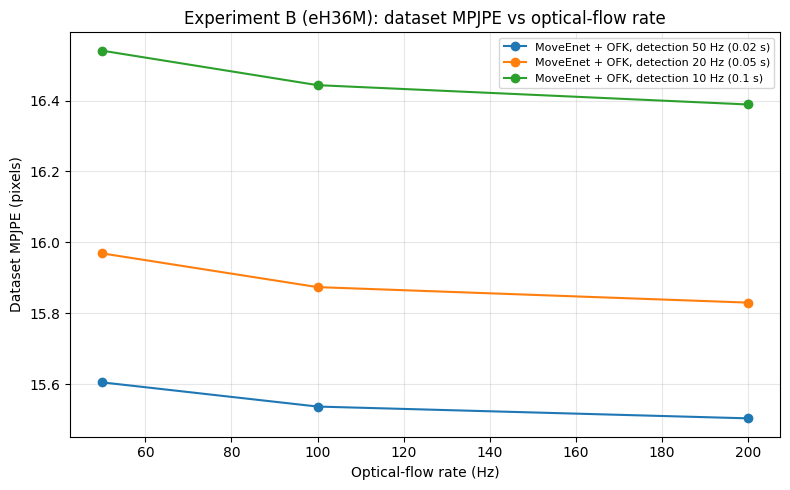

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/pck_0.1_vs_flow_rate_dataset_weighted.png


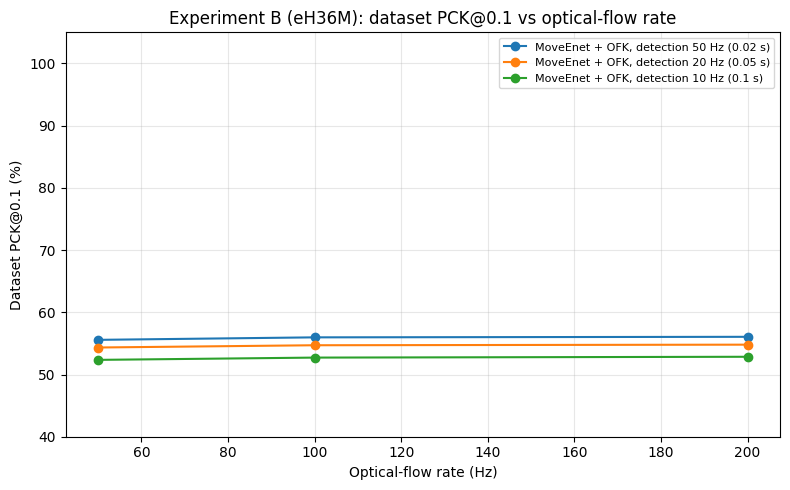

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/pck_0.2_vs_flow_rate_dataset_weighted.png


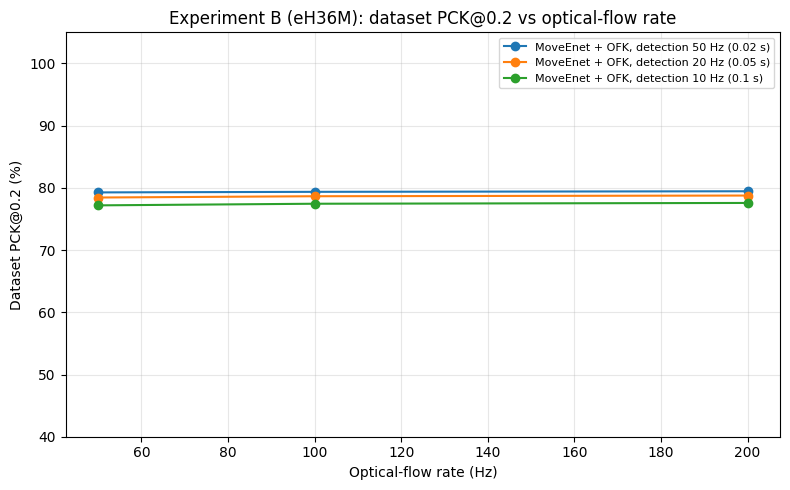

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/pck_0.4_vs_flow_rate_dataset_weighted.png


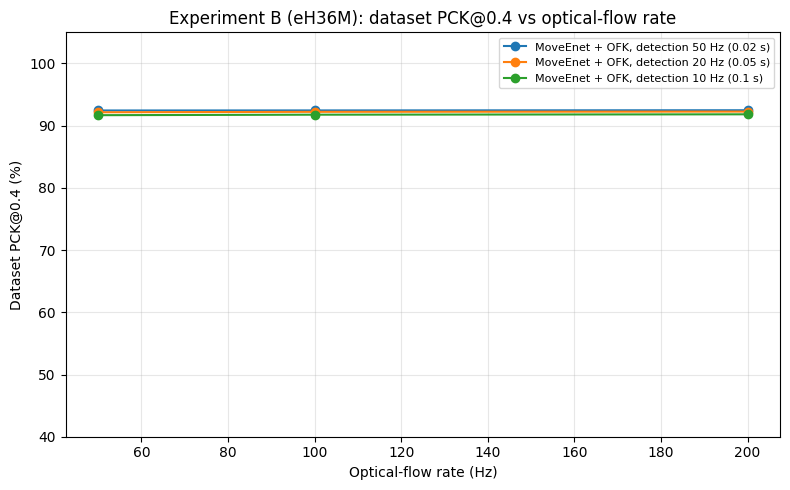

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/pck_0.6_vs_flow_rate_dataset_weighted.png


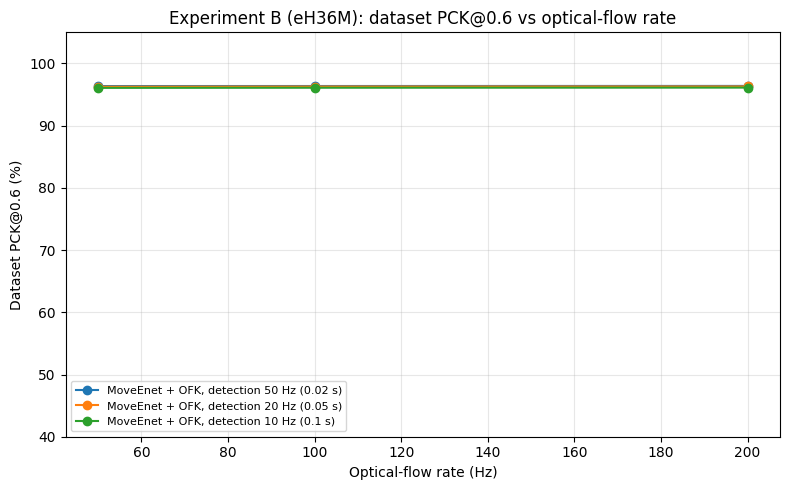

In [7]:
FIG_DIR = ANALYSIS_OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("Saved:", path)

def add_period_secondary_axis(ax):
    def hz_to_s(hz):
        hz = np.asarray(hz, dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            return 1.0 / hz
    def s_to_hz(s):
        s = np.asarray(s, dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            return 1.0 / s
    secax = ax.secondary_xaxis("top", functions=(hz_to_s, s_to_hz))
    secax.set_xlabel("Optical-flow period (s)")
    return secax

def plot_vs_flow(y_col, y_label, title, filename, ylim=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    for method in sorted(summary["method"].dropna().unique()):
        for net_period, sub in summary[summary["method"] == method].groupby("network_period_s"):
            sub = sub.sort_values("flow_rate_hz")
            ax.plot(
                sub["flow_rate_hz"],
                sub[y_col],
                marker="o",
                label=f"{method}, detection {1/net_period:g} Hz ({net_period:g} s)",
            )

    ax.set_xlabel("Optical-flow rate (Hz)")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    savefig(filename)
    plt.show()

plot_vs_flow(
    "mpjpe_px",
    "Dataset MPJPE (pixels)",
    f"Experiment B ({DATASET_LABEL}): dataset MPJPE vs optical-flow rate",
    "mpjpe_vs_flow_rate_dataset_weighted.png",
)

for th in PCK_THRESHOLDS_NORM:
    pck_col = f"pck_{th:.1f}"
    if pck_col not in summary.columns:
        continue

    plot_vs_flow(
        pck_col,
        f"Dataset PCK@{th:.1f} (%)",
        f"Experiment B ({DATASET_LABEL}): dataset PCK@{th:.1f} vs optical-flow rate",
        f"pck_{th:.1f}_vs_flow_rate_dataset_weighted.png",
        ylim=(40, 105),
    )


Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/mpjpe_heatmap.png


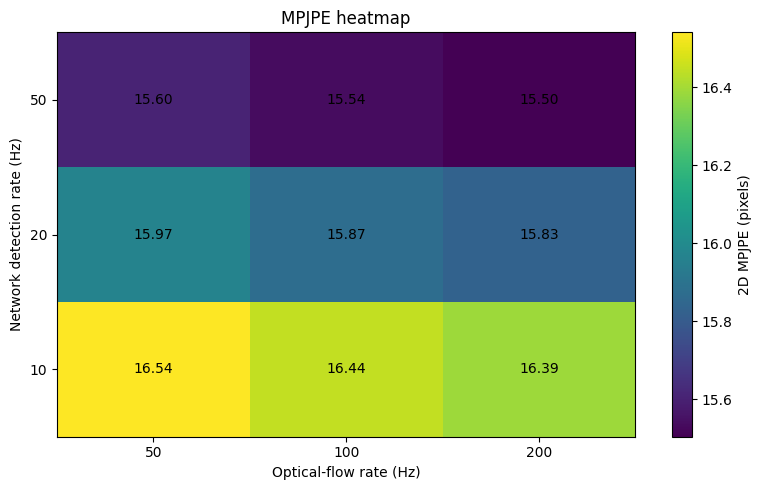

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/normalized_pck_heatmap.png


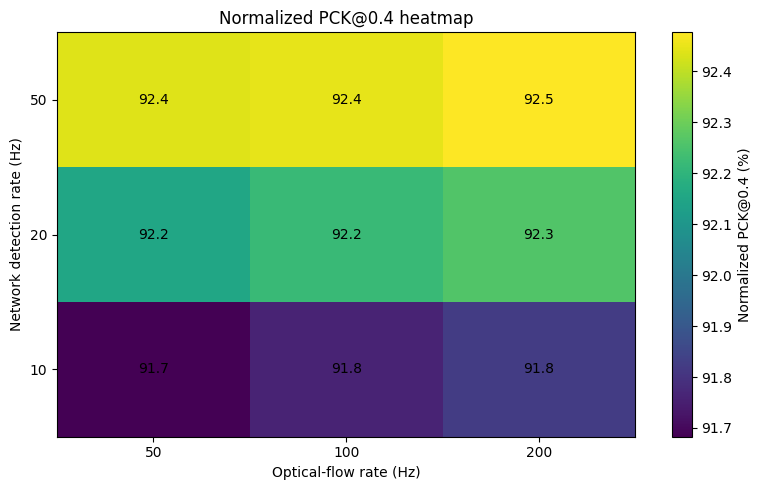

In [8]:
def heatmap(value_col, title, label, filename, fmt=".2f"):
    pivot = summary.pivot_table(
        index="detection_rate_hz",
        columns="flow_rate_hz",
        values=value_col,
        aggfunc="mean",
    ).sort_index(ascending=False).sort_index(axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(pivot.to_numpy(), aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{x:g}" for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{x:g}" for x in pivot.index])
    ax.set_xlabel("Optical-flow rate (Hz)")
    ax.set_ylabel("Network detection rate (Hz)")
    ax.set_title(title)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, format(v, fmt), ha="center", va="center")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label)
    savefig(filename)
    plt.show()
    return pivot

mpjpe_pivot = heatmap(
    "mpjpe_px",
    "MPJPE heatmap",
    "2D MPJPE (pixels)",
    "mpjpe_heatmap.png",
    ".2f",
)

pck_pivot = heatmap(
    f"pck_{PRIMARY_PCK_THRESHOLD:.1f}",
    f"Normalized PCK@{PRIMARY_PCK_THRESHOLD:.1f} heatmap",
    f"Normalized PCK@{PRIMARY_PCK_THRESHOLD:.1f} (%)",
    "normalized_pck_heatmap.png",
    ".1f",
)


## 6b. DHP19 vs eH36M heatmaps with shared scales

This section **does not recompute the experiment metrics**. It loads the dataset-level summary CSV files already produced by the DHP19 and eH36M runs.

- The two MPJPE heatmaps use one shared pixel color scale.
- The two normalized PCK heatmaps use one shared percentage color scale.
- Rows and columns are aligned to the same detection-rate and optical-flow-rate axes.

> Note: the MPJPE values remain expressed in native image pixels. DHP19 and eH36M have different image resolutions; the shared colorbar makes their numeric pixel errors visually comparable but does not resolution-normalize the metric.


Experiment root: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period
DHP19 summary: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/dhp19_full_test/results/analysis_outputs_expB/experimentB_dhp19_summary_by_period.csv
eH36M summary: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_summary_by_period.csv
Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/comparison_outputs_expB/mpjpe_heatmaps_dhp19_vs_eh36m_shared_scale.png


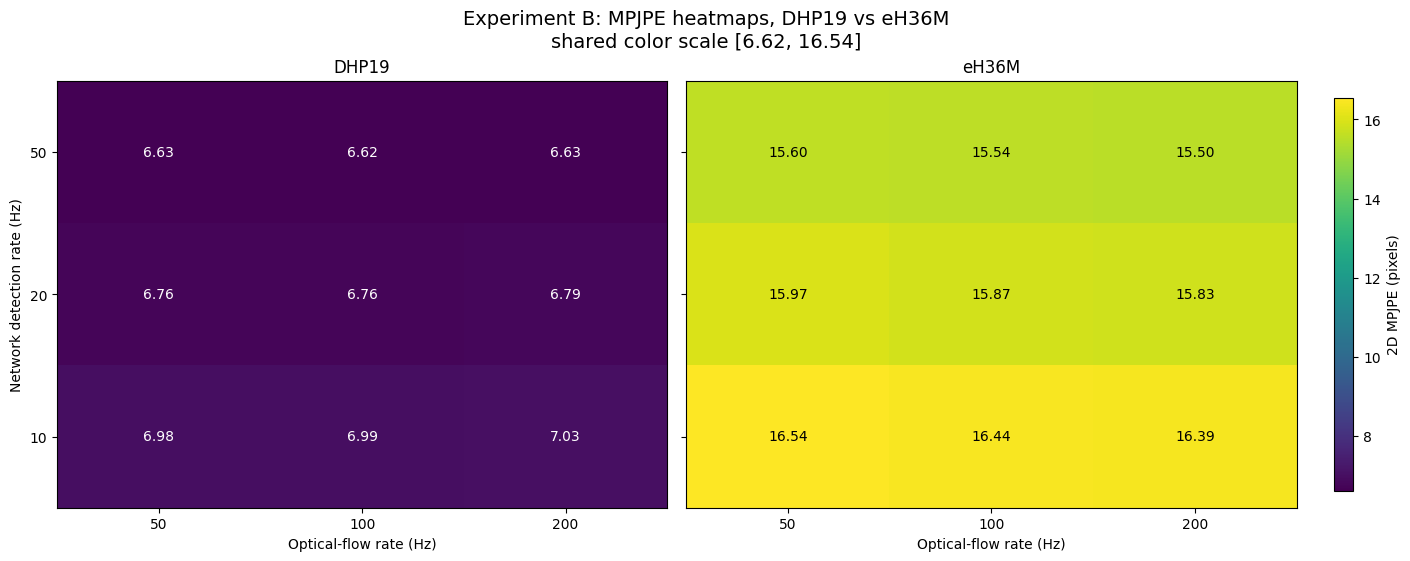

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/comparison_outputs_expB/pck_0p4_heatmaps_dhp19_vs_eh36m_shared_scale.png


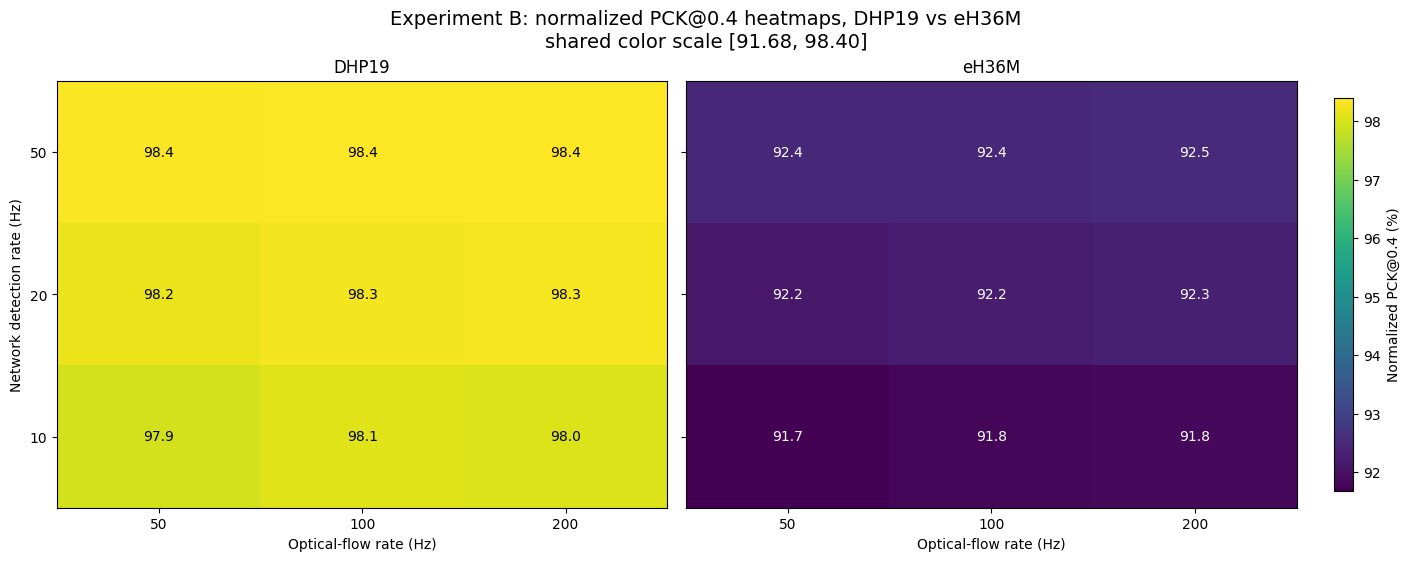


MPJPE shared color limits: 6.618 to 16.541 px
PCK@0.4 shared color limits: 91.683 to 98.396 %


In [10]:
# =============================================================================
# SHARED-SCALE DATASET COMPARISON
# Reuses the summary CSV files already saved by the two completed runs.
# This cell is standalone: it does not need to rerun metric computation.
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PCK_COMPARISON_THRESHOLD = 0.4

# None -> use the common minimum and maximum found across both datasets.
# Set to (0.0, 100.0) for an absolute PCK percentage scale.
PCK_COLOR_LIMITS = None

DATASET_SUMMARIES = {
    "DHP19": (
        "MOFK_dhp19_full_test",
        "experimentB_dhp19_summary_by_period.csv",
    ),
    "eH36M": (
        "MOFK_eh36m_full_test",
        "experimentB_eh36m_summary_by_period.csv",
    ),
}


def _candidate_experiment_roots():
    candidates = []

    # Best candidate when the earlier notebook cells have already been run.
    if "RESULTS" in globals():
        candidates.append(Path(RESULTS).resolve().parent.parent)

    candidates.append(next((p for p in (Path('/data'), Path.home() / 'data') if p.exists()), Path('/data')) / 'MoveEnet_OFK_results')

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if base.name == "expB_accuracy_vs_flow_period":
            candidates.append(base)
        candidates.append(base / "expB_accuracy_vs_flow_period")
        candidates.append(base / "ExpB" / "expB_accuracy_vs_flow_period")

    unique = []
    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            unique.append(candidate)
            seen.add(key)
    return unique


def _summary_paths(experiment_root):
    return {
        label: (
            experiment_root
            / dataset_folder
            / "results"
            / "analysis_outputs_expB"
            / summary_filename
        )
        for label, (dataset_folder, summary_filename) in DATASET_SUMMARIES.items()
    }


EXPERIMENT_ROOT = None
SUMMARY_PATHS = None
checked_paths = []

for candidate_root in _candidate_experiment_roots():
    candidate_paths = _summary_paths(candidate_root)
    checked_paths.extend(candidate_paths.values())
    if all(path.is_file() for path in candidate_paths.values()):
        EXPERIMENT_ROOT = candidate_root
        SUMMARY_PATHS = candidate_paths
        break

if SUMMARY_PATHS is None:
    checked = "\n".join(f"  - {path}" for path in checked_paths)
    raise FileNotFoundError(
        "Could not find both previously computed Experiment-B summary CSV files.\n"
        "Expected one DHP19 summary and one eH36M summary.\n"
        f"Checked:\n{checked}"
    )

print("Experiment root:", EXPERIMENT_ROOT)
for label, path in SUMMARY_PATHS.items():
    print(f"{label} summary: {path}")

summaries = {
    label: pd.read_csv(path)
    for label, path in SUMMARY_PATHS.items()
}

required_common_columns = {
    "detection_rate_hz",
    "flow_rate_hz",
    "mpjpe_px",
}
pck_col = f"pck_{PCK_COMPARISON_THRESHOLD:.1f}"

for label, df in summaries.items():
    missing = required_common_columns.difference(df.columns)
    if pck_col not in df.columns:
        missing.add(pck_col)
    if missing:
        raise KeyError(
            f"{label} summary is missing required columns: {sorted(missing)}"
        )

    # Avoid silently averaging different methods if a future summary contains more
    # than one method. Current Experiment B summaries contain MoveEnet + OFK only.
    if "method" in df.columns:
        methods = df["method"].dropna().unique().tolist()
        if len(methods) > 1:
            raise ValueError(
                f"{label} contains multiple methods {methods}. "
                "Filter the desired method before comparing heatmaps."
            )

all_detection_rates = sorted(
    set().union(*[
        set(df["detection_rate_hz"].dropna().astype(float))
        for df in summaries.values()
    ]),
    reverse=True,
)
all_flow_rates = sorted(
    set().union(*[
        set(df["flow_rate_hz"].dropna().astype(float))
        for df in summaries.values()
    ])
)


def _make_pivot(df, value_col):
    return (
        df.pivot_table(
            index="detection_rate_hz",
            columns="flow_rate_hz",
            values=value_col,
            aggfunc="mean",
        )
        .reindex(index=all_detection_rates, columns=all_flow_rates)
    )


mpjpe_pivots = {
    label: _make_pivot(df, "mpjpe_px")
    for label, df in summaries.items()
}
pck_pivots = {
    label: _make_pivot(df, pck_col)
    for label, df in summaries.items()
}


def _shared_limits(pivots, explicit_limits=None):
    if explicit_limits is not None:
        vmin, vmax = map(float, explicit_limits)
    else:
        finite_values = np.concatenate([
            pivot.to_numpy(dtype=float)[np.isfinite(pivot.to_numpy(dtype=float))]
            for pivot in pivots.values()
        ])
        if finite_values.size == 0:
            raise ValueError("No finite heatmap values were found.")
        vmin = float(finite_values.min())
        vmax = float(finite_values.max())

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin > vmax:
        raise ValueError(f"Invalid shared color limits: {(vmin, vmax)}")
    if np.isclose(vmin, vmax):
        margin = max(abs(vmin) * 0.01, 1e-6)
        vmin -= margin
        vmax += margin
    return vmin, vmax


def _annotate_heatmap(ax, pivot, vmin, vmax, fmt):
    span = vmax - vmin
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.iloc[i, j]
            if pd.isna(value):
                continue
            relative = (float(value) - vmin) / span
            text_color = "white" if relative < 0.52 else "black"
            ax.text(
                j,
                i,
                format(float(value), fmt),
                ha="center",
                va="center",
                color=text_color,
                fontsize=10,
            )


def plot_shared_heatmaps(pivots, metric_title, colorbar_label, filename, fmt, limits=None):
    labels = list(DATASET_SUMMARIES.keys())
    vmin, vmax = _shared_limits(pivots, explicit_limits=limits)

    fig, axes = plt.subplots(
        1,
        len(labels),
        figsize=(14, 5.5),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    images = []
    for ax, label in zip(axes, labels):
        pivot = pivots[label]
        image = ax.imshow(
            pivot.to_numpy(dtype=float),
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        images.append(image)

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{value:g}" for value in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{value:g}" for value in pivot.index])
        ax.set_xlabel("Optical-flow rate (Hz)")
        ax.set_title(label)
        _annotate_heatmap(ax, pivot, vmin, vmax, fmt)

    axes[0].set_ylabel("Network detection rate (Hz)")
    fig.suptitle(
        f"Experiment B: {metric_title}\n"
        f"shared color scale [{vmin:.2f}, {vmax:.2f}]",
        fontsize=14,
    )

    colorbar = fig.colorbar(images[0], ax=axes.tolist(), shrink=0.92, pad=0.03)
    colorbar.set_label(colorbar_label)

    output_dir = EXPERIMENT_ROOT / "comparison_outputs_expB"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print("Saved:", output_path)
    plt.show()

    return vmin, vmax, output_path


mpjpe_vmin, mpjpe_vmax, mpjpe_comparison_path = plot_shared_heatmaps(
    mpjpe_pivots,
    metric_title="MPJPE heatmaps, DHP19 vs eH36M",
    colorbar_label="2D MPJPE (pixels)",
    filename="mpjpe_heatmaps_dhp19_vs_eh36m_shared_scale.png",
    fmt=".2f",
)

pck_vmin, pck_vmax, pck_comparison_path = plot_shared_heatmaps(
    pck_pivots,
    metric_title=f"normalized PCK@{PCK_COMPARISON_THRESHOLD:.1f} heatmaps, DHP19 vs eH36M",
    colorbar_label=f"Normalized PCK@{PCK_COMPARISON_THRESHOLD:.1f} (%)",
    filename=(
        f"pck_{str(f'{PCK_COMPARISON_THRESHOLD:.1f}').replace('.', 'p')}_heatmaps_"
        "dhp19_vs_eh36m_shared_scale.png"
    ),
    fmt=".1f",
    limits=PCK_COLOR_LIMITS,
)

print()
print(f"MPJPE shared color limits: {mpjpe_vmin:.3f} to {mpjpe_vmax:.3f} px")
print(f"PCK@{PCK_COMPARISON_THRESHOLD:.1f} shared color limits: {pck_vmin:.3f} to {pck_vmax:.3f} %")


## 7. Per-joint summary


,flow_period_s,flow_rate_hz,network_period_s,detection_rate_hz,joint,mpjpe_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,0.005,200.0,0.02,50.0,head,8.624539,84.454416,92.511290,97.056010,98.266144
1,0.005,200.0,0.02,50.0,shoulder_right,11.955557,68.963361,87.279161,95.400152,98.210016
2,0.005,200.0,0.02,50.0,shoulder_left,12.288352,64.054214,86.968063,95.384373,98.025954
3,0.005,200.0,0.02,50.0,elbow_right,16.353682,55.060751,77.898000,91.544142,95.485941
4,0.005,200.0,0.02,50.0,elbow_left,17.231137,49.285325,75.132279,90.954105,95.377581
5,0.005,200.0,0.02,50.0,hip_left,11.725138,65.234487,87.515255,95.428116,98.239977
6,0.005,200.0,0.02,50.0,hip_right,11.796851,67.310001,87.699617,95.887522,98.282922
7,0.005,200.0,0.02,50.0,wrist_right,23.148021,34.639477,63.477161,85.957871,92.725014
8,0.005,200.0,0.02,50.0,wrist_left,23.520165,31.366012,61.162456,85.150815,92.962207
9,0.005,200.0,0.02,50.0,knee_right,14.415336,56.493497,80.393571,94.256632,97.601104


Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_per_joint_summary.csv
Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/per_joint_mpjpe_flow_50Hzppng


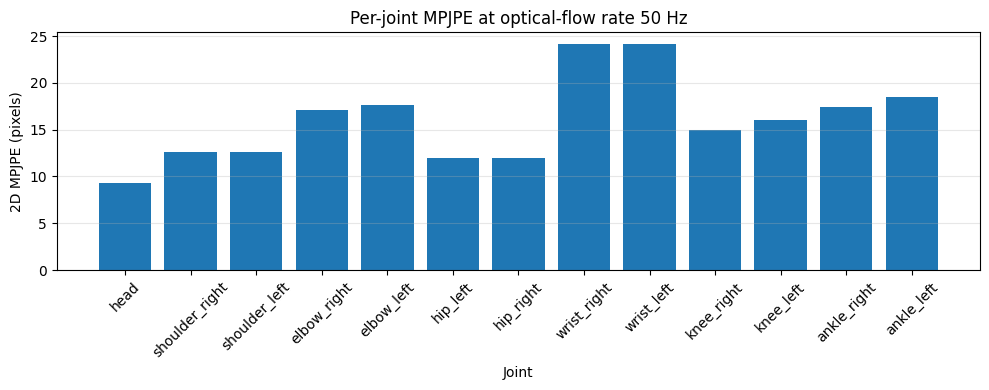

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/per_joint_mpjpe_flow_100Hzppng


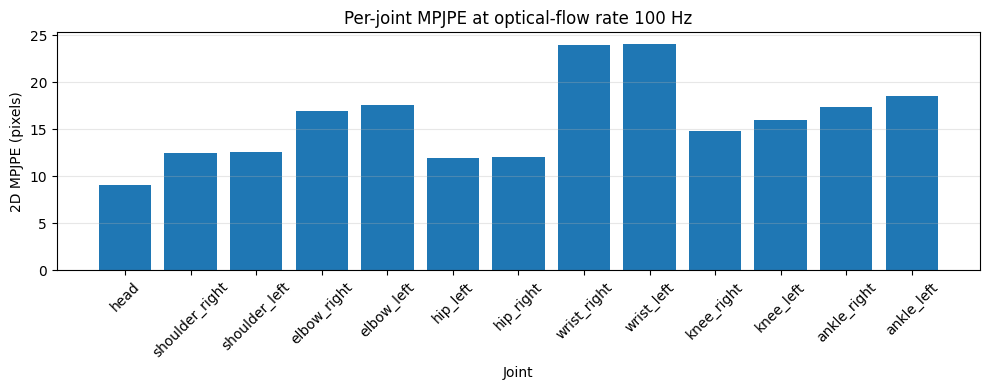

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/per_joint_mpjpe_flow_200Hzppng


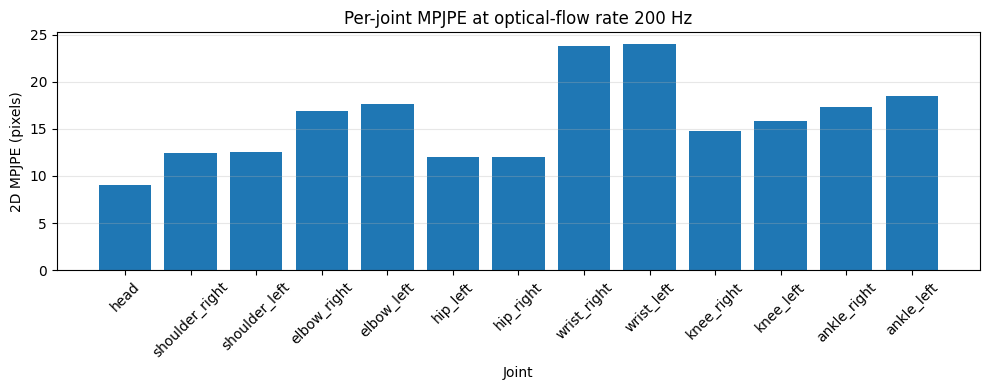

In [ ]:
joint_rows = []

for _, r in summary.iterrows():
    for joint in joint_names:
        row = {
            "flow_period_s": r["flow_period_s"],
            "flow_rate_hz": r["flow_rate_hz"],
            "network_period_s": r["network_period_s"],
            "detection_rate_hz": r["detection_rate_hz"],
            "joint": joint,
            "mpjpe_px": r[f"mpjpe_{joint}"],
        }
        for th in PCK_THRESHOLDS_NORM:
            row[f"pck_{th:.1f}"] = r[f"pck_{th:.1f}_{joint}"]
        joint_rows.append(row)

df_joint_summary = pd.DataFrame(joint_rows)
display(df_joint_summary.head(30))

joint_summary_path = ANALYSIS_OUT_DIR / f"{OUTPUT_PREFIX}_per_joint_summary.csv"
df_joint_summary.to_csv(joint_summary_path, index=False)
print("Saved:", joint_summary_path)

for flow_rate, sub in df_joint_summary.groupby("flow_rate_hz"):
    d = sub.groupby("joint", as_index=False).agg(mpjpe_px=("mpjpe_px", "mean"))
    d["joint"] = pd.Categorical(d["joint"], categories=joint_names, ordered=True)
    d = d.sort_values("joint")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(d["joint"].astype(str), d["mpjpe_px"])
    ax.set_xlabel("Joint")
    ax.set_ylabel("2D MPJPE (pixels)")
    ax.set_title(f"Per-joint MPJPE at optical-flow rate {flow_rate:g} Hz")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
    savefig(f"per_joint_mpjpe_flow_{flow_rate:g}Hz.png".replace(".", "p"))
    plt.show()


# 8. Specific desired images

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/normalized_pck_0.2_vs_flow_rate_zoom.png


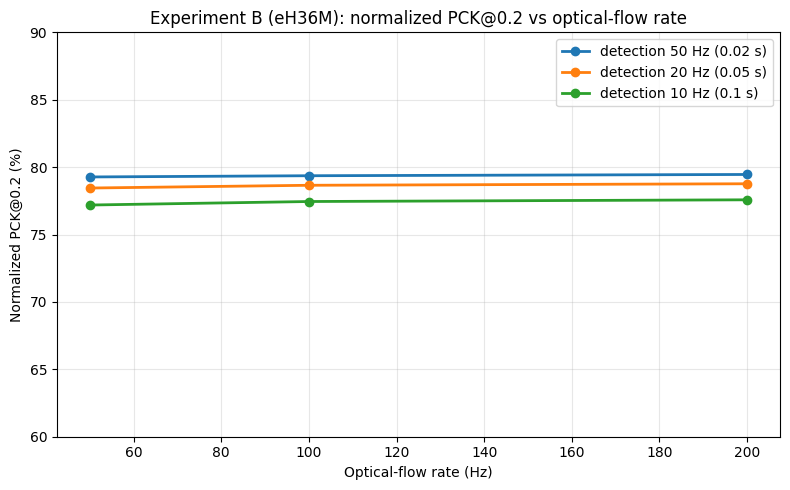

In [ ]:
# Plot normalized PCK@0.2 with adjustable y-axis zoom

PCK_THRESHOLD = 0.2
PCK_COL = f"pck_{PCK_THRESHOLD:.1f}"

YLIM_PCK02 = (60, 90)

fig, ax = plt.subplots(figsize=(8, 5))

for net_period, sub in summary.groupby("network_period_s"):
    sub = sub.sort_values("flow_rate_hz")

    ax.plot(
        sub["flow_rate_hz"],
        sub[PCK_COL],
        marker="o",
        linewidth=2,
        label=f"detection {1 / net_period:g} Hz ({net_period:g} s)",
    )

ax.set_xlabel("Optical-flow rate (Hz)")
ax.set_ylabel(f"Normalized PCK@{PCK_THRESHOLD:.1f} (%)")
ax.set_title(f"Experiment B ({DATASET_LABEL}): normalized PCK@{PCK_THRESHOLD:.1f} vs optical-flow rate")
ax.grid(True, alpha=0.3)
ax.legend()

if YLIM_PCK02 is not None:
    ax.set_ylim(YLIM_PCK02)


savefig(f"normalized_pck_{PCK_THRESHOLD:.1f}_vs_flow_rate_zoom.png")
plt.show()

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/figures/normalized_pck_0.4_vs_flow_rate_zoom.png


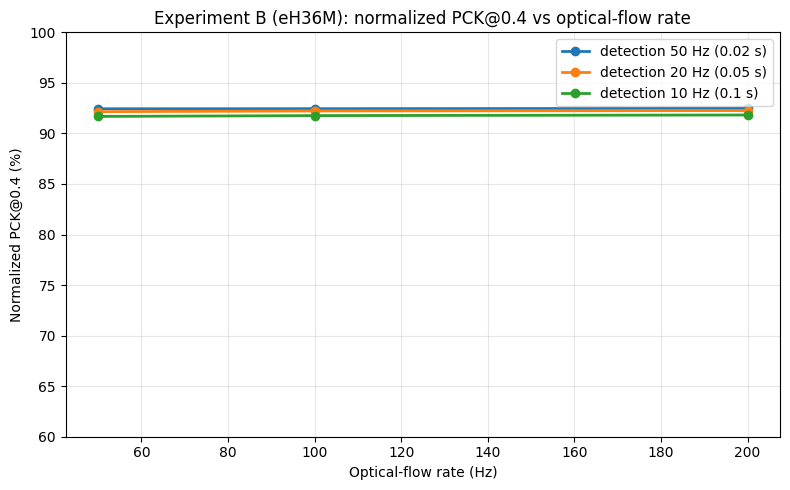

In [ ]:
# Plot normalized PCK@0.4 with adjustable y-axis zoom

PCK_THRESHOLD = 0.4
PCK_COL = f"pck_{PCK_THRESHOLD:.1f}"

# Modify this to zoom in.
# Example: (65, 80)
# Use None to let matplotlib choose automatically.
# YLIM_PCK04 = None
YLIM_PCK04 = (60, 100)

fig, ax = plt.subplots(figsize=(8, 5))

for net_period, sub in summary.groupby("network_period_s"):
    sub = sub.sort_values("flow_rate_hz")

    ax.plot(
        sub["flow_rate_hz"],
        sub[PCK_COL],
        marker="o",
        linewidth=2,
        label=f"detection {1 / net_period:g} Hz ({net_period:g} s)",
    )

ax.set_xlabel("Optical-flow rate (Hz)")
ax.set_ylabel(f"Normalized PCK@{PCK_THRESHOLD:.1f} (%)")
ax.set_title(f"Experiment B ({DATASET_LABEL}): normalized PCK@{PCK_THRESHOLD:.1f} vs optical-flow rate")
ax.grid(True, alpha=0.3)
ax.legend()

if YLIM_PCK04 is not None:
    ax.set_ylim(YLIM_PCK04)



savefig(f"normalized_pck_{PCK_THRESHOLD:.1f}_vs_flow_rate_zoom.png")
plt.show()

## 9. Diminishing returns and text summary


In [ ]:
pck_col = f"pck_{PRIMARY_PCK_THRESHOLD:.1f}"

return_rows = []
for net_period, sub in summary.groupby("network_period_s"):
    sub = sub.sort_values("flow_rate_hz")
    baseline = sub.iloc[0]
    best_mpjpe = sub["mpjpe_px"].min()
    best_pck = sub[pck_col].max()

    for _, r in sub.iterrows():
        extra_hz = r["flow_rate_hz"] - baseline["flow_rate_hz"]
        mpjpe_gain = baseline["mpjpe_px"] - r["mpjpe_px"]
        pck_gain = r[pck_col] - baseline[pck_col]
        return_rows.append({
            "network_period_s": net_period,
            "detection_rate_hz": r["detection_rate_hz"],
            "flow_period_s": r["flow_period_s"],
            "flow_rate_hz": r["flow_rate_hz"],
            "mpjpe_px": r["mpjpe_px"],
            pck_col: r[pck_col],
            "mpjpe_gain_vs_slowest_flow_px": mpjpe_gain,
            "pck_gain_vs_slowest_flow_pctpt": pck_gain,
            "extra_flow_rate_vs_slowest_hz": extra_hz,
            "mpjpe_gain_px_per_extra_flow_hz": mpjpe_gain / extra_hz if extra_hz > 0 else np.nan,
            "pck_gain_pctpt_per_extra_flow_hz": pck_gain / extra_hz if extra_hz > 0 else np.nan,
            "mpjpe_gap_to_best_px": r["mpjpe_px"] - best_mpjpe,
            "pck_gap_to_best_pctpt": best_pck - r[pck_col],
        })

returns = pd.DataFrame(return_rows)
display(returns)

returns_path = ANALYSIS_OUT_DIR / f"{OUTPUT_PREFIX}_diminishing_returns.csv"
returns.to_csv(returns_path, index=False)
print("Saved:", returns_path)

MPJPE_PLATEAU_TOLERANCE_PX = 1.0
PCK_PLATEAU_TOLERANCE_PCTPT = 1.0

plateau_rows = []
for net_period, sub in summary.groupby("network_period_s"):
    sub = sub.sort_values("flow_rate_hz")
    best_mpjpe = sub["mpjpe_px"].min()
    best_pck = sub[pck_col].max()

    candidates = sub[
        (sub["mpjpe_px"] <= best_mpjpe + MPJPE_PLATEAU_TOLERANCE_PX) &
        (sub[pck_col] >= best_pck - PCK_PLATEAU_TOLERANCE_PCTPT)
    ].sort_values("flow_rate_hz")

    if len(candidates):
        c = candidates.iloc[0]
        plateau_rows.append({
            "network_period_s": net_period,
            "detection_rate_hz": c["detection_rate_hz"],
            "recommended_flow_period_s": c["flow_period_s"],
            "recommended_flow_rate_hz": c["flow_rate_hz"],
            "mpjpe_px": c["mpjpe_px"],
            pck_col: c[pck_col],
        })

plateau = pd.DataFrame(plateau_rows)
display(plateau)

plateau_path = ANALYSIS_OUT_DIR / f"{OUTPUT_PREFIX}_plateau_candidates.csv"
plateau.to_csv(plateau_path, index=False)
print("Saved:", plateau_path)

def fmt(x, digits=3):
    if pd.isna(x):
        return "n/a"
    return f"{x:.{digits}f}"

best_mpjpe = summary.loc[summary["mpjpe_px"].idxmin()]
best_pck = summary.loc[summary[pck_col].idxmax()]

lines = []
lines.append("Best configuration by MPJPE:")
lines.append(
    f"  network_period={best_mpjpe['network_period_s']:g} s "
    f"({best_mpjpe['detection_rate_hz']:g} Hz), "
    f"flow_period={best_mpjpe['flow_period_s']:g} s "
    f"({best_mpjpe['flow_rate_hz']:g} Hz), "
    f"MPJPE={fmt(best_mpjpe['mpjpe_px'], 3)} px, "
    f"normalized PCK@{PRIMARY_PCK_THRESHOLD:.1f}={fmt(best_mpjpe[pck_col], 2)}%."
)

lines.append("")
lines.append("Best configuration by normalized PCK:")
lines.append(
    f"  network_period={best_pck['network_period_s']:g} s "
    f"({best_pck['detection_rate_hz']:g} Hz), "
    f"flow_period={best_pck['flow_period_s']:g} s "
    f"({best_pck['flow_rate_hz']:g} Hz), "
    f"MPJPE={fmt(best_pck['mpjpe_px'], 3)} px, "
    f"normalized PCK@{PRIMARY_PCK_THRESHOLD:.1f}={fmt(best_pck[pck_col], 2)}%."
)

if len(plateau):
    lines.append("")
    lines.append("Low-cost plateau candidates:")
    for _, r in plateau.iterrows():
        lines.append(
            f"  detection {r['detection_rate_hz']:g} Hz: "
            f"flow {r['recommended_flow_rate_hz']:g} Hz "
            f"({r['recommended_flow_period_s']:g} s), "
            f"MPJPE={fmt(r['mpjpe_px'], 3)} px, "
            f"normalized PCK@{PRIMARY_PCK_THRESHOLD:.1f}={fmt(r[pck_col], 2)}%."
        )

text = "\n".join(lines)
print(text)

text_path = ANALYSIS_OUT_DIR / f"{OUTPUT_PREFIX}_interpretation.txt"
text_path.write_text(text, encoding="utf-8")
print("\nSaved:", text_path)


,network_period_s,detection_rate_hz,flow_period_s,flow_rate_hz,mpjpe_px,pck_0.4,mpjpe_gain_vs_slowest_flow_px,pck_gain_vs_slowest_flow_pctpt,extra_flow_rate_vs_slowest_hz,mpjpe_gain_px_per_extra_flow_hz,pck_gain_pctpt_per_extra_flow_hz,mpjpe_gap_to_best_px,pck_gap_to_best_pctpt
0,0.02,50.0,0.020,50.0,15.604788,92.439368,0.000000,0.000000,0.0,NaN,NaN,0.101395,0.037390
1,0.02,50.0,0.010,100.0,15.536635,92.447765,0.068153,0.008397,50.0,0.001363,0.000168,0.033242,0.028993
2,0.02,50.0,0.005,200.0,15.503393,92.476758,0.101395,0.037390,150.0,0.000676,0.000249,0.000000,0.000000
3,0.05,20.0,0.020,50.0,15.968719,92.153246,0.000000,0.000000,0.0,NaN,NaN,0.138752,0.107661
4,0.05,20.0,0.010,100.0,15.873646,92.221542,0.095073,0.068296,50.0,0.001901,0.001366,0.043680,0.039364
5,0.05,20.0,0.005,200.0,15.829966,92.260907,0.138752,0.107661,150.0,0.000925,0.000718,0.000000,0.000000
6,0.10,10.0,0.020,50.0,16.540623,91.682832,0.000000,0.000000,0.0,NaN,NaN,0.151675,0.140288
7,0.10,10.0,0.010,100.0,16.443474,91.763174,0.097150,0.080342,50.0,0.001943,0.001607,0.054525,0.059946
8,0.10,10.0,0.005,200.0,16.388949,91.823119,0.151675,0.140288,150.0,0.001011,0.000935,0.000000,0.000000


Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_diminishing_returns.csv


,network_period_s,detection_rate_hz,recommended_flow_period_s,recommended_flow_rate_hz,mpjpe_px,pck_0.4
0,0.02,50.0,0.02,50.0,15.604788,92.439368
1,0.05,20.0,0.02,50.0,15.968719,92.153246
2,0.10,10.0,0.02,50.0,16.540623,91.682832


Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_plateau_candidates.csv
Best configuration by MPJPE:
  network_period=0.02 s (50 Hz), flow_period=0.005 s (200 Hz), MPJPE=15.503 px, normalized PCK@0.4=92.48%.

Best configuration by normalized PCK:
  network_period=0.02 s (50 Hz), flow_period=0.005 s (200 Hz), MPJPE=15.503 px, normalized PCK@0.4=92.48%.

Low-cost plateau candidates:
  detection 50 Hz: flow 50 Hz (0.02 s), MPJPE=15.605 px, normalized PCK@0.4=92.44%.
  detection 20 Hz: flow 50 Hz (0.02 s), MPJPE=15.969 px, normalized PCK@0.4=92.15%.
  detection 10 Hz: flow 50 Hz (0.02 s), MPJPE=16.541 px, normalized PCK@0.4=91.68%.

Saved: /workspace/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/eh36m_full_test/results/analysis_outputs_expB/experimentB_eh36m_interpretation.txt
